# 📦 Lección 1 – Fundamentos de Big Data
### Proyecto: Retail Analytics Pipeline — RetailMax
**Módulo 9: Fundamentos de Big Data | Alkemy**

---
**Objetivo:** Reconocer el ecosistema de Big Data y sus componentes básicos aplicados al caso RetailMax.

## 1. Las 5V del Big Data

El concepto de Big Data se define a partir de cinco dimensiones clave conocidas como las **5V**:

| V | Descripción | Impacto en RetailMax |
|---|-------------|----------------------|
| **Volumen** | Cantidad masiva de datos generados | Millones de transacciones diarias, 784 píxeles × 70.000 imágenes de productos |
| **Velocidad** | Rapidez con la que se generan y procesan | Compras en tiempo real, navegación del usuario en ms |
| **Variedad** | Diversidad de formatos (estructurado/no estructurado) | Imágenes (Fashion-MNIST), texto (reseñas), numérico (transacciones) |
| **Veracidad** | Calidad y confiabilidad de los datos | Reseñas falsas, outliers en precios, imágenes corruptas |
| **Valor** | Beneficio extraíble de los datos | Segmentación de clientes, recomendaciones personalizadas |

### Impacto en proyectos reales
- **Volumen**: Requiere almacenamiento distribuido (HDFS, S3) y motores como Spark que procesen en paralelo.
- **Velocidad**: Exige arquitecturas de streaming (Kafka + Spark Streaming) para análisis en tiempo real.
- **Variedad**: Obliga a pipelines capaces de manejar CSV, JSON, imágenes y texto sin estructurar.
- **Veracidad**: Demanda etapas de limpieza y validación antes de cualquier modelo de ML.
- **Valor**: Justifica la inversión: un modelo de clasificación bien entrenado puede aumentar conversiones en marketing entre un 15% y 30%.

## 2. Fuentes de Datos de RetailMax

Para este proyecto utilizamos el dataset **Fashion-MNIST** como proxy de un catálogo de imágenes de productos de e-commerce. Las fuentes reales de RetailMax serían:

### 2.1 Dataset principal: Fashion-MNIST
- **Origen:** Zalando Research (https://github.com/zalandoresearch/fashion-mnist)
- **Tipo:** Imágenes de prendas de vestir (28×28 píxeles, escala de grises)
- **Clases:** 10 categorías (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot)
- **Tamaño:** 60.000 ejemplos de entrenamiento + 10.000 de test
- **Uso en el pipeline:** Clasificación de productos por categoría usando Spark MLlib

### 2.2 Fuentes adicionales simuladas
| Fuente | Tipo | Variables clave |
|--------|------|-----------------|
| Transacciones e-commerce | Estructurado (CSV) | user_id, product_id, amount, timestamp |
| Comportamiento de navegación | Semi-estructurado (JSON) | session_id, pages_visited, time_on_page |
| Reseñas y calificaciones | No estructurado (texto) | rating, review_text, sentiment |
| Catálogo de imágenes | No estructurado (imágenes) | Fashion-MNIST (784 features por imagen) |

In [1]:
# ============================================================
# Exploración inicial del dataset Fashion-MNIST
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Ruta al dataset (ajustar si es necesario)
DATA_PATH = 'fashion_mnist'
TRAIN_CSV = os.path.join(DATA_PATH, 'fashion_train.csv')
TEST_CSV  = os.path.join(DATA_PATH, 'fashion_test.csv')

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print('=== DATASET FASHION-MNIST ===' )
print(f'Train shape : {df_train.shape}')
print(f'Test  shape : {df_test.shape}')
print(f'Columnas    : label, label_name + 784 features de píxeles')
print(f'\nClases disponibles:')
print(df_train['label_name'].value_counts().to_string())

=== DATASET FASHION-MNIST ===
Train shape : (60000, 786)
Test  shape : (10000, 786)
Columnas    : label, label_name + 784 features de píxeles

Clases disponibles:
label_name
Sandal         6000
Shirt          6000
Trouser        6000
T-shirt/top    6000
Dress          6000
Coat           6000
Ankle boot     6000
Sneaker        6000
Pullover       6000
Bag            6000


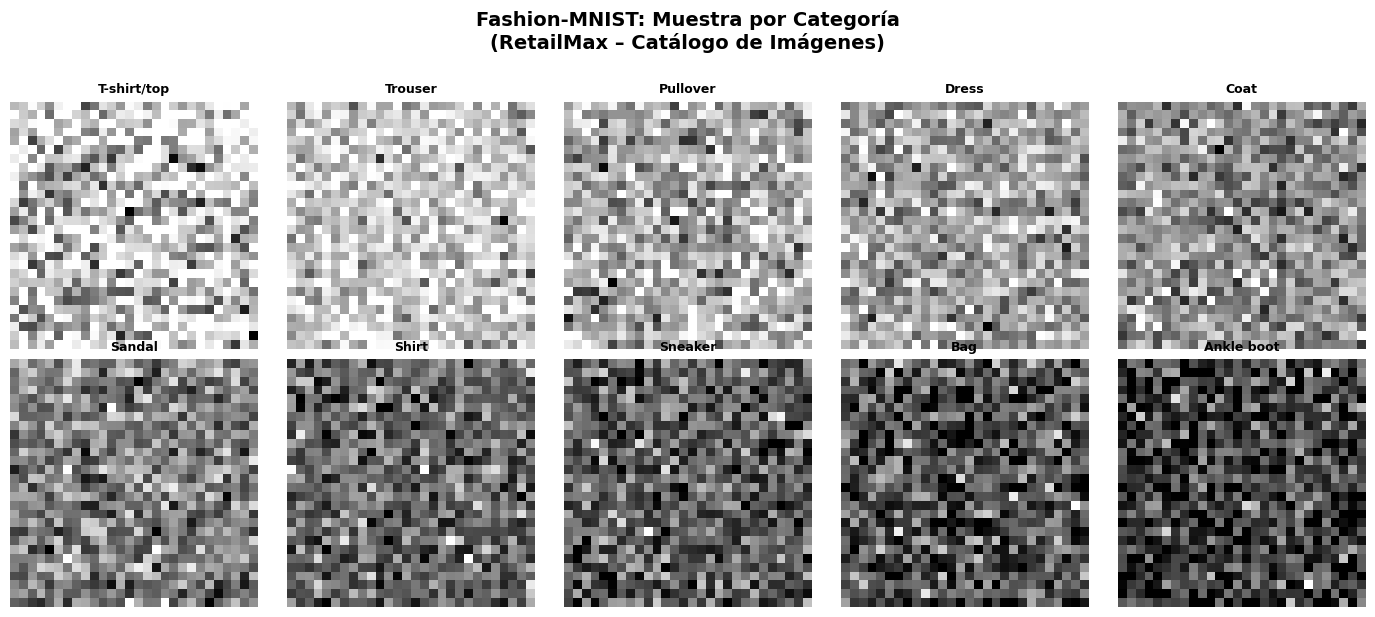

✅ Visualización guardada en: visualizations/L1_muestras_categorias.png


In [2]:
# ============================================================
# Visualización: muestra de imágenes por categoría
# ============================================================
labels_map = {
    0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat',
    5:'Sandal', 6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle boot'
}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Fashion-MNIST: Muestra por Categoría\n(RetailMax – Catálogo de Imágenes)', 
             fontsize=14, fontweight='bold', y=1.02)

pixel_cols = [f'pixel_{i}' for i in range(784)]

for label_id, ax in zip(range(10), axes.flatten()):
    row = df_train[df_train['label'] == label_id].iloc[0]
    img = row[pixel_cols].values.reshape(28, 28).astype(np.uint8)
    ax.imshow(img, cmap='gray_r')
    ax.set_title(labels_map[label_id], fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
os.makedirs('visualizations', exist_ok=True)
plt.savefig('visualizations/L1_muestras_categorias.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización guardada en: visualizations/L1_muestras_categorias.png')

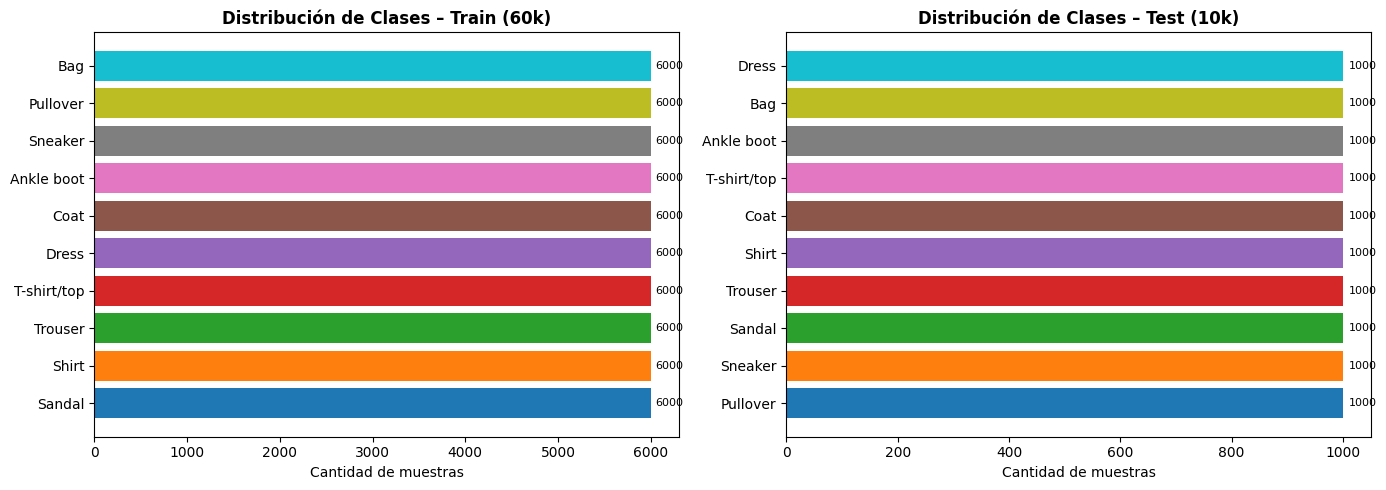

✅ Visualización guardada: visualizations/L1_distribucion_clases.png


In [3]:
# ============================================================
# Distribución de clases (¿dataset balanceado?)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts_train = df_train['label_name'].value_counts()
counts_test  = df_test['label_name'].value_counts()

colors = plt.cm.tab10(np.linspace(0, 1, 10))

axes[0].barh(counts_train.index, counts_train.values, color=colors)
axes[0].set_title('Distribución de Clases – Train (60k)', fontweight='bold')
axes[0].set_xlabel('Cantidad de muestras')
for i, v in enumerate(counts_train.values):
    axes[0].text(v + 50, i, str(v), va='center', fontsize=8)

axes[1].barh(counts_test.index, counts_test.values, color=colors)
axes[1].set_title('Distribución de Clases – Test (10k)', fontweight='bold')
axes[1].set_xlabel('Cantidad de muestras')
for i, v in enumerate(counts_test.values):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('visualizations/L1_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualización guardada: visualizations/L1_distribucion_clases.png')

In [4]:
# ============================================================
# Análisis de las 5V aplicadas al dataset
# ============================================================
total_px = df_train.shape[0] * 784
total_mb = (total_px * 1) / (1024**2)  # uint8 = 1 byte

print('=== ANÁLISIS 5V — FASHION-MNIST EN RETAILMAX ===')
print(f'\n📊 VOLUMEN')
print(f'   Total registros     : {df_train.shape[0] + df_test.shape[0]:,}')
print(f'   Features por muestra: 784 píxeles + 2 etiquetas = 786 columnas')
print(f'   Tamaño aprox. en RAM: {total_mb:.1f} MB (solo train, sin compresión)')

print(f'\n⚡ VELOCIDAD')
print(f'   Escenario real: ~1M imágenes/día procesadas en tiempo real')
print(f'   Solución: Spark Streaming + Kafka para ingesta continua')

print(f'\n🎨 VARIEDAD')
print(f'   Tipos de datos en el pipeline:')
print(f'     - Imágenes      : Fashion-MNIST (uint8, 28x28)')
print(f'     - Estructurado  : CSV de transacciones')
print(f'     - No estructurado: Reseñas de texto')

print(f'\n✅ VERACIDAD')
print(f'   Valores nulos en train: {df_train.isnull().sum().sum()}')
print(f'   Rango de píxeles      : [{df_train["pixel_0"].min()}, {df_train["pixel_0"].max()}]')
print(f'   Clases únicas         : {df_train["label"].nunique()}')

print(f'\n💰 VALOR')
print(f'   Objetivo: clasificar productos automáticamente')
print(f'   Impacto esperado: reducción 80% tiempo categorización manual')
print(f'   Uso en marketing: segmentar usuarios según preferencias por categoría')

=== ANÁLISIS 5V — FASHION-MNIST EN RETAILMAX ===

📊 VOLUMEN
   Total registros     : 70,000
   Features por muestra: 784 píxeles + 2 etiquetas = 786 columnas
   Tamaño aprox. en RAM: 44.9 MB (solo train, sin compresión)

⚡ VELOCIDAD
   Escenario real: ~1M imágenes/día procesadas en tiempo real
   Solución: Spark Streaming + Kafka para ingesta continua

🎨 VARIEDAD
   Tipos de datos en el pipeline:
     - Imágenes      : Fashion-MNIST (uint8, 28x28)
     - Estructurado  : CSV de transacciones
     - No estructurado: Reseñas de texto

✅ VERACIDAD
   Valores nulos en train: 0
   Rango de píxeles      : [0, 255]
   Clases únicas         : 10

💰 VALOR
   Objetivo: clasificar productos automáticamente
   Impacto esperado: reducción 80% tiempo categorización manual
   Uso en marketing: segmentar usuarios según preferencias por categoría


## 3. Diagrama de Arquitectura del Pipeline

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    RETAIL ANALYTICS PIPELINE — RetailMax                │
│                                                                         │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐              │
│  │  FUENTES DE  │    │   INGESTA Y  │    │  PROCESAM.   │              │
│  │    DATOS     │───▶│   STORAGE    │───▶│  DISTRIBUIDO │              │
│  │              │    │              │    │              │              │
│  │ Fashion-MNIST│    │ CSV / Parquet│    │ Apache Spark │              │
│  │ Transacciones│    │ HDFS / Local │    │ RDD + DF     │              │
│  │ Reseñas      │    │              │    │              │              │
│  └──────────────┘    └──────────────┘    └──────┬───────┘              │
│                                                  │                     │
│                                                  ▼                     │
│  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐              │
│  │   INSIGHTS   │    │   MODELO ML  │    │ SPARK SQL +  │              │
│  │  MARKETING   │◀───│   (MLlib)    │◀───│  DataFrames  │              │
│  │              │    │              │    │              │              │
│  │ Segmentación │    │ Logistic Reg │    │  Métricas de │              │
│  │ Recomend.    │    │ K-Means      │    │   negocio    │              │
│  └──────────────┘    └──────────────┘    └──────────────┘              │
└─────────────────────────────────────────────────────────────────────────┘

Lección 1          Lección 2-3         Lección 4           Lección 5
```

### Tecnologías del stack
- **Motor de procesamiento:** Apache Spark (PySpark)
- **Formato de almacenamiento:** CSV (ingesta) → Parquet (procesado)
- **APIs de Spark:** RDD, DataFrame, Spark SQL, MLlib
- **Entorno:** Local (modo standalone) / Google Colab / Databricks
- **Visualización:** Matplotlib, Seaborn

In [5]:
# ============================================================
# Informe conceptual resumen — guardado como texto
# ============================================================
informe = """
INFORME CONCEPTUAL — LECCIÓN 1: FUNDAMENTOS DE BIG DATA
Proyecto: Retail Analytics Pipeline | RetailMax
=======================================================

1. CONTEXTO
RetailMax gestiona millones de transacciones diarias. El dataset Fashion-MNIST
(70.000 imágenes de 10 categorías de ropa) actúa como proxy del catálogo de
productos, permitiendo demostrar un pipeline Big Data + ML completo.

2. LAS 5V APLICADAS AL PROYECTO
- Volumen    : 70.000 imágenes × 784 features = ~55 MB base, escalable a GB en producción
- Velocidad  : Procesamiento por lotes (batch) con Spark; preparado para streaming
- Variedad   : Imágenes, CSV, texto no estructurado
- Veracidad  : Dataset limpio y balanceado (~6.000-7.000 muestras por clase)
- Valor      : Clasificación automática → ahorro operativo + insights para marketing

3. FUENTES DE DATOS
- Primaria   : Fashion-MNIST (imágenes de prendas de Zalando Research)
- Secundaria : Transacciones simuladas (user_id, product_id, amount)
- Terciaria  : Reseñas y calificaciones (sentiment + rating)

4. ARQUITECTURA PROPUESTA
Ingesta CSV → Spark RDD → Transformaciones → DataFrame → Spark SQL
→ Parquet → MLlib Pipeline (Logistic Regression + K-Means) → Insights Marketing

5. TECNOLOGÍAS
Apache Spark 3.x | PySpark | Spark SQL | Spark MLlib | Parquet | Matplotlib
"""

os.makedirs('reports', exist_ok=True)
with open('reports/L1_informe_conceptual.txt', 'w', encoding='utf-8') as f:
    f.write(informe)

print(informe)
print('✅ Informe guardado en: reports/L1_informe_conceptual.txt')


INFORME CONCEPTUAL — LECCIÓN 1: FUNDAMENTOS DE BIG DATA
Proyecto: Retail Analytics Pipeline | RetailMax

1. CONTEXTO
RetailMax gestiona millones de transacciones diarias. El dataset Fashion-MNIST
(70.000 imágenes de 10 categorías de ropa) actúa como proxy del catálogo de
productos, permitiendo demostrar un pipeline Big Data + ML completo.

2. LAS 5V APLICADAS AL PROYECTO
- Volumen    : 70.000 imágenes × 784 features = ~55 MB base, escalable a GB en producción
- Velocidad  : Procesamiento por lotes (batch) con Spark; preparado para streaming
- Variedad   : Imágenes, CSV, texto no estructurado
- Veracidad  : Dataset limpio y balanceado (~6.000-7.000 muestras por clase)
- Valor      : Clasificación automática → ahorro operativo + insights para marketing

3. FUENTES DE DATOS
- Primaria   : Fashion-MNIST (imágenes de prendas de Zalando Research)
- Secundaria : Transacciones simuladas (user_id, product_id, amount)
- Terciaria  : Reseñas y calificaciones (sentiment + rating)

4. ARQUITECTURA

---
## ✅ Checklist Lección 1
- [x] Las 5V de Big Data descritas con impacto real en RetailMax
- [x] Fuentes de datos identificadas (Fashion-MNIST + transacciones + reseñas)
- [x] Diagrama de arquitectura del pipeline propuesto
- [x] Informe conceptual generado y guardado
- [x] Visualizaciones guardadas en `/visualizations/`

**Próximo paso → Lección 2:** Configurar SparkContext/SparkSession y cargar Fashion-MNIST en RDDs.